# Loading dataset and performing EDA + modeling for heart disease prediction

In [55]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, recall_score, precision_score, f1_score
from sklearn.utils import resample


# 1. Load Dataset

In [56]:

data_path = Path(r"..\Healthcare\dataset\heart.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path}")


df = pd.read_csv(data_path)
print("Dataset loaded from:", data_path)
print("\nShape:", df.shape)

Dataset loaded from: ..\Healthcare\dataset\heart.csv

Shape: (1025, 14)


### Output Directory for Analyis output

In [57]:
# output directory for analysis visualizations
out_dir = Path(r"..\Healthcare\analysis_output")
out_dir.mkdir(exist_ok=True)

# 2. Quick look and check for Missing and Duplicate Values 

In [58]:
df.head ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [59]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [60]:
dupvalues = df.duplicated().any()
if dupvalues:
    no_of_dup = df.duplicated().sum()
    print(f"\nThere are {no_of_dup} duplicate rows in the dataset.")
else:
    print("\nNo duplicate rows found in the dataset.")


There are 723 duplicate rows in the dataset.


### Dropping Duplicate Rows

In [61]:
# df = df.drop_duplicates()
# df.shape

In [62]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# 3. Identifying And Evaluating Target Column

In [63]:
# Identified our target column as "target"
from turtle import position


print("\nTarget value counts:")
print(df["target"].value_counts(dropna=False))
sns.countplot(x="target", data=df, hue = 'target')
plt.title('Heart Disease Class Distribution')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Heart Disease'])
plt.legend(title='Target', labels=['No Disease (0)', 'Heart Disease (1)'])
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig(out_dir / "Heart Disesase dist.png", bbox_inches='tight')
plt.close()
plt.show()


Target value counts:
target
1    526
0    499
Name: count, dtype: int64


### Inbalanced Ratio

In [64]:
imbalance_ratio = df['target'].value_counts(normalize=True)
print("Class distribution (%):")
print(imbalance_ratio * 100)

Class distribution (%):
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


# 4.Heat Map

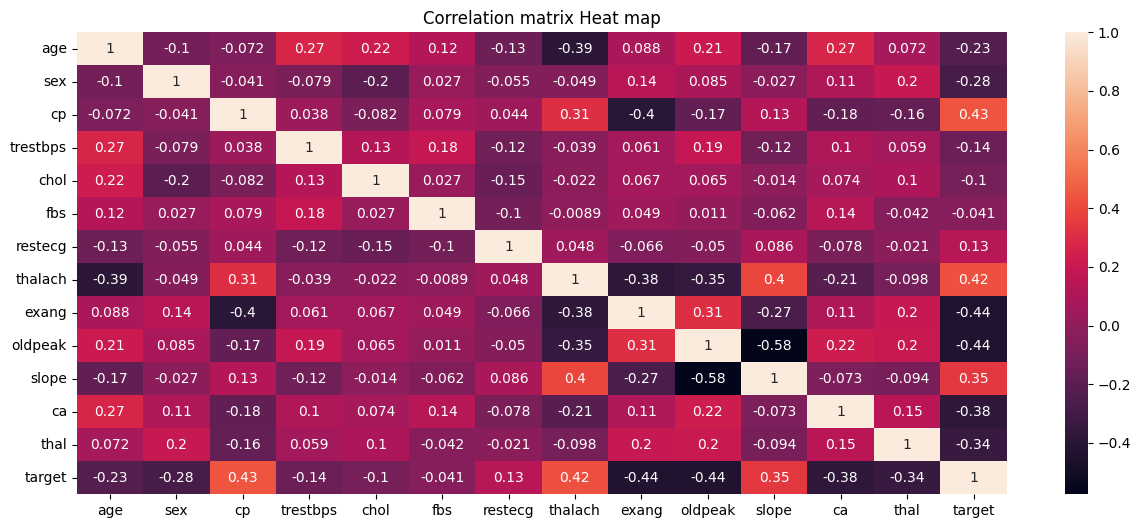

In [65]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# plt.figure(figsize=(8,6))
# plt.imshow(corr, aspect='auto')
# plt.colorbar()
# plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
# plt.yticks(range(len(corr.columns)), corr.columns)
# plt.tight_layout()
# plt.savefig(out_dir / "correlaation_matrix.png", bbox_inches='tight')
# plt.close()

plt.figure(figsize=(15,6))
plt.title("Correlation matrix Heat map")
sns.heatmap(df.corr(),annot=True)
plt.savefig(out_dir / "heatmap.png", bbox_inches='tight')
plt.show()
plt.close()

# 5. Exploratory Analysis

### 1. Gender Distribution within Dataset

In [66]:
sns.countplot(x='sex', data=df)    
plt.title('Distribution of Gender ')
plt.xticks([0, 1], ['Female', 'Male'])
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.savefig(out_dir / "gender dist.png", bbox_inches='tight')
# plt.show()
plt.close()

### 2. Distribution of Heart Diseases among Males and Females 

In [67]:
sns.countplot(x='sex', hue='target', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Distribution of Heart Disease by Gender')
plt.legend(title='Heart Disease', labels=['No Heart diseases', 'with Heart diseases'])
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count') 
plt.savefig(out_dir / "dist among gender.png", bbox_inches='tight')
# plt.show()
plt.close()

### 3. Distribution of Heart Diseases by Age 

In [68]:
sns.displot( df['age'],bins = 20, kde =True)
# plt.xticks([0, 1], ['Female', 'Male'])
# plt.title('Distribution of Heart Disease by Gender')
# plt.legend(title='Heart Disease', labels=['No Heart diseases', 'with Heart diseases'])
# plt.xlabel('Gender (0 = Female, 1 = Male)')
# plt.ylabel('Count') 
plt.savefig(out_dir / "dist by age.png", bbox_inches='tight')
# plt.show()
plt.close()

### 4. Distribution of Chest Pain Type Within Data set

In [69]:
sns.countplot(x='cp', data=df)    
plt.title('Distribution chest pain tyoe  ')
plt.xticks([0, 1, 2, 3], ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'])
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.savefig(out_dir / "chest pain dist.png", bbox_inches='tight')
# plt.show()
plt.close()

### 5. Distribution of Heart Disease by Chest Pain

In [70]:
sns.countplot(data = df, x='cp', hue='target')
plt.title('Chest Pain Type by Heart Disease')
plt.legend(title='Heart Disease', labels=['No Heart diseases', 'with Heart diseases'])
plt.xticks([0, 1, 2, 3], ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'])
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.savefig(out_dir / "dist by chest pain.png", bbox_inches='tight')
# plt.show()
plt.close()

### 6. Distribution of Heart Diseases by Blood Presure Levels

In [71]:
df['trestbps'].hist(edgecolor='black')
plt.title('Distribution of Resting Blood Pressure')
plt.savefig(out_dir / "bist by blood pressure.png", bbox_inches='tight')
# plt.show()
plt.close()

### 7. Distribution of Heart Diseases by Serum Cholesterol

In [72]:
df['chol'].hist(edgecolor='black')
plt.title('Distribution of Cholesterol Levels')
plt.savefig(out_dir / "dist by cholesterol.png", bbox_inches='tight')
# plt.show()
plt.close()

# 6. Training the Machine Learning Models

Spliting Data For Training 

In [73]:
x, y = df.drop('target', axis=1), df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,test_size=0.2, random_state=9)
print("\nTrain shape:", x_train.shape, "Test shape:", x_test.shape)

# stratify=y ensures the same class ratio in both train and test sets.


Train shape: (820, 13) Test shape: (205, 13)


### Subsetting the data for required features 

In [ ]:
# Choose a subset of important features
selected_features = ['age', 'cp', 'chol', 'thalach', 'trestbps']

# Create new training and test sets using only those features
x_train = x_train[selected_features]
x_test = x_test[selected_features]


In [75]:
# Checking class imbalance
imbalance_ratio = df['target'].value_counts(normalize=True)
print("Class distribution (%):")
print(imbalance_ratio * 100)


Class distribution (%):
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


## I. Balancing The data

In [76]:
# Separate majority and minority classes
majority = df[df.target == 1]
minority = df[df.target == 0]

# Upsample minority
minority_upsampled = resample(
    minority,
    replace=True,                     # sample with replacement
    n_samples=len(majority),          # match majority count
    random_state=42                   # for reproducibility
)

# Combine back
df = pd.concat([majority, minority_upsampled])

# # Check new balance
# print(df['target'].value_counts())
# sns.countplot(x='target', data=df, hue = 'target')
# plt.title('Balanced Dataset (After Upsampling)')
# plt.show()


In [77]:
# majority_downsampled = resample(
#     majority,
#     replace=False,
#     n_samples=len(minority),
#     random_state=42
# )
# balanced_df = pd.concat([majority_downsampled, minority])

## II. Train Test Split 

### Scalling for Scale Sensitive Models 

In [78]:
scaler = StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

## III. Training Scale Insensitive Models 

In [79]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=9
)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
nb_clf = GaussianNB(
    priors=[0.457, 0.543]
)
nb_clf.fit(x_train, y_train)

,priors,"[0.457, 0.543]"
,var_smoothing,1e-09


In [81]:
# hgb_clf= HistGradientBoostingClassifier(
#     class_weight='balanced',
#     random_state=42
#     )
# hgb_clf.fit(x_train, y_train)

gb_clf = GradientBoostingClassifier()
gb_clf.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### IV. Training Scale Sensitive Models 

In [82]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [83]:
log = LogisticRegression(
    class_weight='balanced', 
    random_state=9, 
    max_iter=1000,
    solver='liblinear' 
)
log.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,9
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [84]:
svc = SVC(
    class_weight='balanced',
    kernel='rbf',
    random_state=42
)
svc.fit(x_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


## V. Evaluating Models 

### evaluating the accuracy, Precision, recall and F1-score for the models 

In [85]:
y_pred_rf = rf.predict(x_test)
y_pred_nb = nb_clf.predict(x_test)
# y_pred_hgb = hgb_clf.predict(x_test)
y_pred_gb = gb_clf.predict(x_test)
y_pred_knn = knn.predict(x_test_scaled)
y_pred_log = log.predict(x_test_scaled)
y_pred_svc = svc.predict(x_test_scaled)


In [86]:
# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Naive Bayes metrics
nb_clf_accuracy = accuracy_score(y_test, y_pred_nb)
nb_clf_precision = precision_score(y_test, y_pred_nb)
nb_clf_recall = recall_score(y_test, y_pred_nb)
nb_clf_f1 = f1_score(y_test, y_pred_nb)

# # Gradient Boosting metrics
# hgb_clf_accuracy = accuracy_score(y_test, y_pred_hgb)
# hgb_clf_precision = precision_score(y_test, y_pred_hgb)
# hgb_clf_recall = recall_score(y_test, y_pred_hgb)
# hgb_clf_f1 = f1_score(y_test, y_pred_hgb)

# Gradient Boosting metrics
gb_clf_accuracy = accuracy_score(y_test, y_pred_gb)
gb_clf_precision = precision_score(y_test, y_pred_gb)
gb_clf_recall = recall_score(y_test, y_pred_gb)
gb_clf_f1 = f1_score(y_test, y_pred_gb)

# K-Nearest Neighbors metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# Support Vector Classifier metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc)
svc_recall = recall_score(y_test, y_pred_svc)
svc_f1 = f1_score(y_test, y_pred_svc)


In [87]:
# Compile results into a DataFrame
from tkinter import N


results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Naive Bayes",
        "Gradient Boosting",
        "K-Nearest Neighbors",
        "Logistic Regression",
        "Support Vector Classifier"
        ],
    "Accuracy": [
        rf_accuracy, 
        nb_clf_accuracy, 
        # hgb_clf_accuracy, 
        gb_clf_accuracy,
        knn_accuracy, 
        log_accuracy, 
        svc_accuracy
        ],
    "Precision": [
        rf_precision, 
        nb_clf_precision, 
        # hgb_clf_precision, 
        gb_clf_precision,
        knn_precision, 
        log_precision, 
        svc_precision
        ],
    "Recall (Sensitivity)": [
        rf_recall, 
        nb_clf_recall, 
        # hgb_clf_recall, 
        gb_clf_recall, 
        knn_recall, 
        log_recall, 
        svc_recall
        ],
    "F1-score": [
        rf_f1,
        nb_clf_recall,
        # hgb_clf_f1,
        gb_clf_f1,
        knn_f1,
        log_f1,
        svc_f1
        ]
})

print("\nModel Performance Comparison:")
print(results.round(3))



Model Performance Comparison:
                       Model  Accuracy  Precision  Recall (Sensitivity)  \
0              Random Forest     1.000      1.000                 1.000   
1                Naive Bayes     0.756      0.704                 0.905   
2          Gradient Boosting     0.937      0.911                 0.971   
3        K-Nearest Neighbors     1.000      1.000                 1.000   
4        Logistic Regression     0.737      0.698                 0.857   
5  Support Vector Classifier     0.790      0.742                 0.905   

   F1-score  
0     1.000  
1     0.905  
2     0.940  
3     1.000  
4     0.769  
5     0.815  


## VI. Visualizing Area Under The Curve(A.U.C)

a. Random Forest

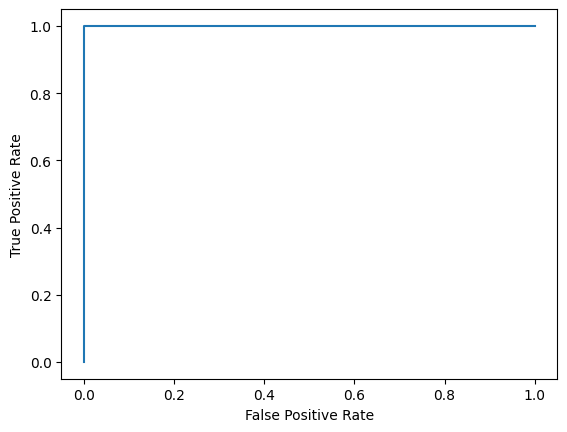

Area under the curve : 1.0


In [88]:
y_prob_rf = rf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr)
# plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('Area under the curve :', roc_auc_score(y_test, y_prob_rf))


b. Naive Bayes Classifier

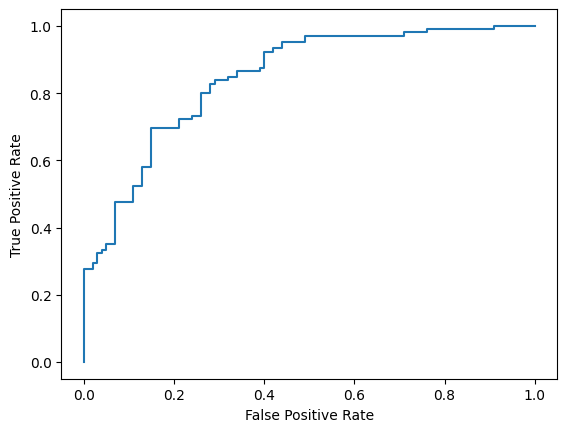

Area under the curve : 0.8459047619047619


In [89]:
y_prob_nb_clf = nb_clf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb_clf)
plt.plot(fpr, tpr)
# plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('Area under the curve :', roc_auc_score(y_test, y_prob_nb_clf))

c. Gradient Boosting Classifier

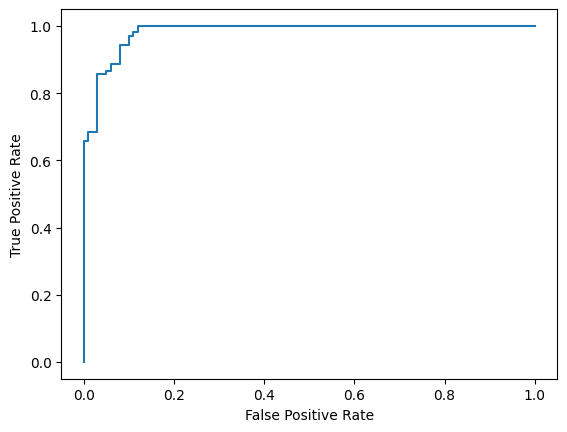

Area under the curve : 0.9821904761904763


In [90]:
# y_prob = hgb_clf.predict_proba(x_test)[:, 1]
y_prob_gb_clf = gb_clf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb_clf)
plt.plot(fpr, tpr)
# plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('Area under the curve :', roc_auc_score(y_test, y_prob_gb_clf))

d. K Nearest Neighbour

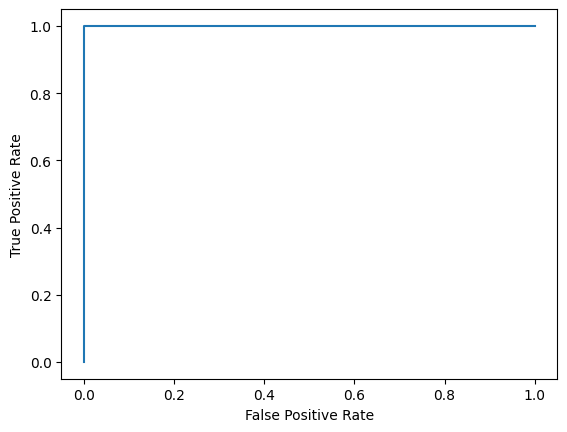

Area under the curve : 1.0


In [91]:
y_prob_knn = knn.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
plt.plot(fpr, tpr)
# plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('Area under the curve :', roc_auc_score(y_test, y_prob_knn))

e. Logistic Regression

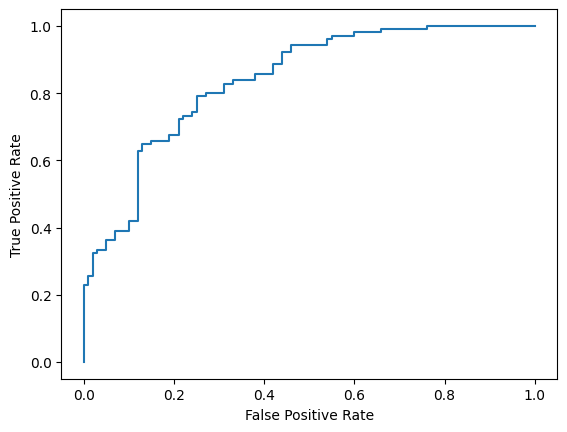

Area under the curve : 0.8387619047619048


In [92]:
y_prob_log = log.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
plt.plot(fpr, tpr)
# plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(auc(fpr, tpr)))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('Area under the curve :', roc_auc_score(y_test, y_prob_log))

## VII. Hyperparameter Tuning

In [93]:

# # Define hyperparameter grid
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'class_weight': [None, 'balanced']
# }

# # Grid search
# grid_search = GridSearchCV(
#     estimator=log,
#     param_grid=param_grid,
#     scoring='recall',   # prioritize catching heart disease cases
#     cv=5,
#     n_jobs=-1,
#     verbose=2
# )

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}


rf = RandomForestClassifier(n_jobs=-1, random_state=9)



grid_search = GridSearchCV(rf, param_grid, scoring='recall', cv=3, n_jobs=-1, verbose=2)
grid_search.fit(x_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
best_rf = grid_search.best_estimator_

In [95]:
best_rf

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205


Confusion Matrix:
 [[100   0]
 [  0 105]]


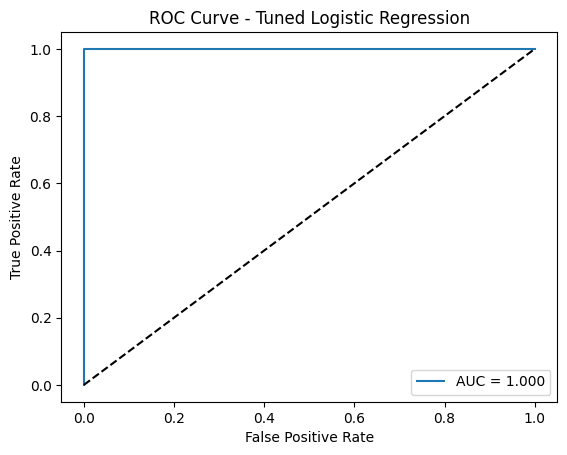

In [96]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(x_test_scaled)
y_prob_rf= best_rf.predict_proba(x_test_scaled)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.show()


## VIII. Feature Importances

In [97]:


# Get feature importance from tuned Logistic Regression
# feature_importance = pd.DataFrame({
#     'Feature': x_train.columns,
#     'Importance': np.abs(best_log.coef_[0])   # use absolute values
# }).sort_values(by='Importance', ascending=False)



# # Plot
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='Black')
# plt.gca().invert_yaxis()  # highest importance at the top
# plt.xlabel('Absolute Coefficient Value')
# plt.title('Feature Importance - Logistic Regression')
# plt.show()


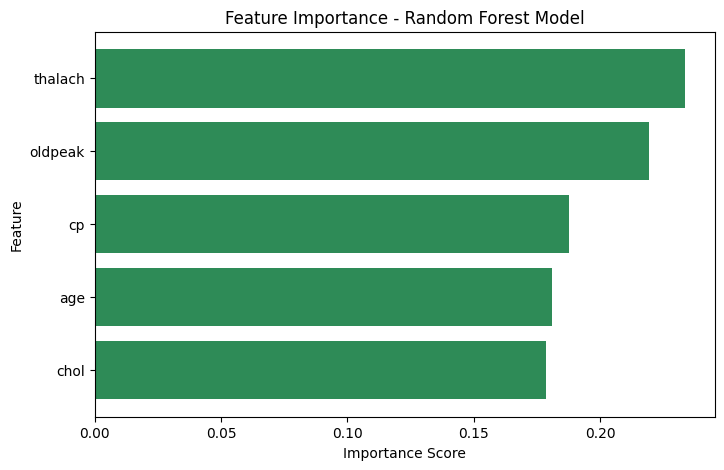

In [106]:

# Get feature importance from tuned Random Forest Clasifier
rf_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(8, 5))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='seagreen')
plt.gca().invert_yaxis()  # highest importance at top
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Text(0.5, 1.0, 'Feature Correlation Heatmap')

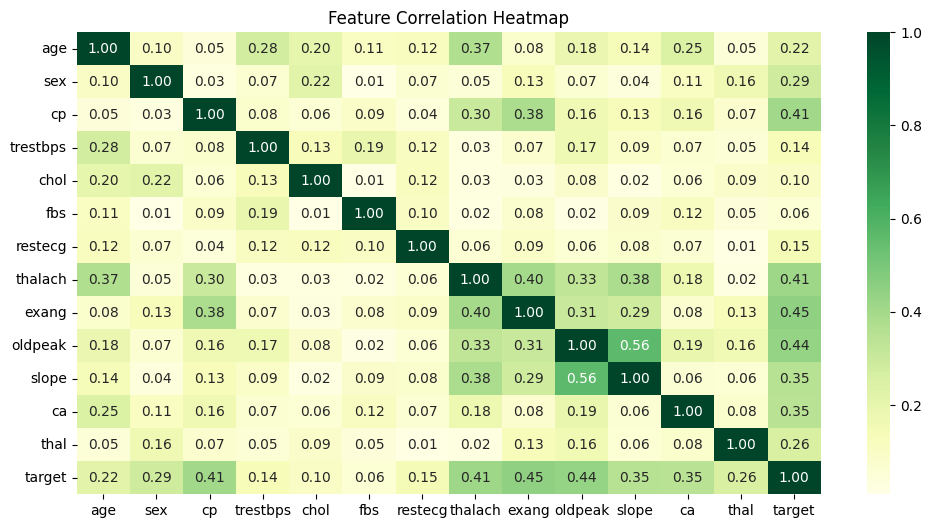

In [99]:
plt.figure(figsize=(12, 6))
sns.heatmap(abs(df.corr()), annot=True, cmap='YlGn', fmt=".2f")
plt.title("Feature Correlation Heatmap")

In [100]:

def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    print(f"\n{name} - Accuracy: {acc:.4f}  ROC-AUC: {roc:.4f}")
    print("Classification report:")
    print(classification_report(y_true, y_pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model("Random Forest (best)", y_test, y_pred_rf, y_prob_rf)




Random Forest (best) - Accuracy: 1.0000  ROC-AUC: 1.0000
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion matrix:
[[100   0]
 [  0 105]]


In [101]:
evaluate_model("Naive Bayes (best)", y_test, y_pred_rf, y_prob_nb_clf)




Naive Bayes (best) - Accuracy: 1.0000  ROC-AUC: 0.8459
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion matrix:
[[100   0]
 [  0 105]]


In [102]:
evaluate_model("Gradient Boosting (best)", y_test, y_pred_rf, y_prob_gb_clf)



Gradient Boosting (best) - Accuracy: 1.0000  ROC-AUC: 0.9822
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion matrix:
[[100   0]
 [  0 105]]


In [103]:
evaluate_model("K Nearest Neighbours(best)", y_test, y_pred_rf, y_prob_knn)



K Nearest Neighbours(best) - Accuracy: 1.0000  ROC-AUC: 1.0000
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion matrix:
[[100   0]
 [  0 105]]


In [104]:
evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)


Logistic Regression - Accuracy: 0.7366  ROC-AUC: 0.8388
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69       100
           1       0.70      0.86      0.77       105

    accuracy                           0.74       205
   macro avg       0.75      0.73      0.73       205
weighted avg       0.75      0.74      0.73       205

Confusion matrix:
[[61 39]
 [15 90]]
